
# **Task 1**

/tmp/ipykernel_5571/838419331.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



Missing Values Handled....

Selected Features:
 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

Data split into training and testing sets!

Model training completed!

Model Evaluation:
Mean Absolute Error (MAE): 39345.21026666667
Mean Squared Error (MSE): 3315046418.020424
R2 Score: 0.7367657879959226


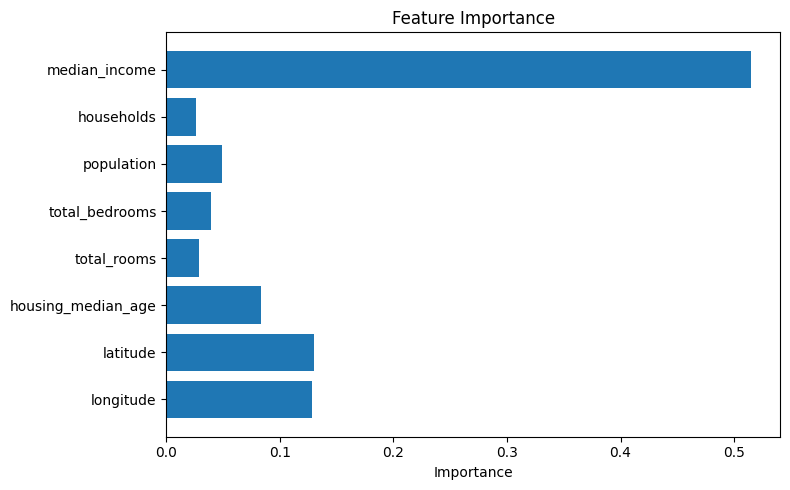


Predicted Price for the New House: 428686.3


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("/content/sample_data/california_housing_test.csv")

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
  df[col].fillna(df[col].median(), inplace=True)

print("\nMissing Values Handled....")



target = "median_house_value"
X = df.drop(target, axis=1)
y = df[target]
print("\nSelected Features:\n", X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData split into training and testing sets!")

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nModel training completed!")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)


importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

new_house = pd.DataFrame({
    'longitude': [-122.23],
    'latitude': [37.88],
    'housing_median_age': [41],
    'total_rooms': [880],
    'total_bedrooms': [129],
    'population': [322],
    'households': [126],
    'median_income': [8.3252]
})

preedicted_price = model.predict(new_house)
print("\nPredicted Price for the New House:", preedicted_price[0])


# **Task 2**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import kagglehub
import os

path = kagglehub.dataset_download("venky73/spam-mails-dataset")
df = pd.read_csv("/kaggle/input/spam-mails-dataset/spam_ham_dataset.csv")

df.drop(columns=['Unnamed: 0'], inplace=True)
df.dropna(inplace=True)

df['label_num'] = df['label_num'].astype(int)
print("Data cleaned Successfully")


vectorizer = TfidfVectorizer(stop_words='english',max_features=5000)
X = vectorizer.fit_transform(df['text'])
y = df['label_num']
print("\nText converted to numerical features!")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("\nModel training completed!")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Evaluation:")
print("Accuracy:", accuracy)

def predict_email(email_text):
  email_vector = vectorizer.transform([email_text])
  prediction = model.predict(email_vector)
  return "SPAM" if prediction == 1 else "NOT SPAM"

test_email = "Congratulations! You won a free lottery. Click here now!"
result = predict_email(test_email)

print("\nTest Email:", test_email)
print("Prediction:", result)

Using Colab cache for faster access to the 'spam-mails-dataset' dataset.
Data cleaned Successfully

Text converted to numerical features!

Model training completed!

Model Evaluation:
Accuracy: 0.9864734299516909

Test Email: Congratulations! You won a free lottery. Click here now!
Prediction: SPAM


# **Task 3**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import kagglehub
import os

df = pd.read_csv("/kaggle/input/online-retail-customer-churn-dataset/online_retail_customer_churn.csv")
df.drop(columns=['Customer_ID'], inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
  df[col].fillna(df[col].median(), inplace=True)
cat_cols = df.select_dtypes(include=[object]).columns
for col in cat_cols:
  df[col].fillna(df[col].mode(), inplace=True)
print("\nMissing Values Handled")

for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
  df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
print("\nOutliers Handled")

le_dict = {}

for col in cat_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  le_dict[col] = le

print("\nCategorical variables encoded!")

target = 'Target_Churn'
X = df.drop(target, axis=1)
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

print("\nSVM Model training completed!")

y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("\nSVM Model Evaluation:")
print("Accuracy:", accuracy_svm)

new_customer = pd.DataFrame({
    'Age': [30],
    'Gender': ['Male'],
    'Annual_Income': [60],
    'Total_Spend': [500],
    'Years_as_Customer': [3],
    'Num_of_Purchases': [20],
    'Average_Transaction_Amount': [25],
    'Num_of_Returns': [1],
    'Num_of_Support_Contacts': [2],
    'Satisfaction_Score': [4],
    'Last_Purchase_Days_Ago': [10],
    'Email_Opt_In': [True],
    'Promotion_Response': ['Responded']
})

for col in new_customer.columns:
  if col in le_dict:
    new_customer[col] = le_dict[col].transform(new_customer[col])

new_Scaled = scaler.transform(new_customer)

prediction_svm = svm_model.predict(new_Scaled)
print("\nNew Customer Prediction (1=High Value / 0=Low Value):", prediction_svm)



Missing Values Handled

Outliers Handled

Categorical variables encoded!

SVM Model training completed!

SVM Model Evaluation:
Accuracy: 0.53

New Customer Prediction (1=High Value / 0=Low Value): [ True]


/tmp/ipykernel_5571/2016949714.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_5571/2016949714.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

# **Lab 11 Task 1**

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("/kaggle/input/mall-customer/Mall_Customers.csv")

df = df.drop("CustomerID", axis=1)

le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"])

# -------------------------------
#  PART 1: WITHOUT SCALING
# -------------------------------
X_no_scale = df.values

kmeans_no_scale = KMeans(n_clusters=5, random_state=42)
y_no_scale = kmeans_no_scale.fit_predict(X_no_scale)

print("Cluster centers WITHOUT scaling:")
print(kmeans_no_scale.cluster_centers_)

# -------------------------------
#  PART 2: WITH SCALING (EXCEPT AGE)
# -------------------------------

df_scaled = df.copy()

age_column = df_scaled["Age"]

features_to_scale = df_scaled.drop("Age", axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale)

X_scaled = np.column_stack((age_column, scaled_features))

kmeans_scaled = KMeans(n_clusters=5, random_state=42)
y_scaled = kmeans_scaled.fit_predict(X_scaled)

print("\nCluster centers WITH scaling (Age not scaled):")
print(kmeans_scaled.cluster_centers_)

Cluster centers WITHOUT scaling:
[[  0.38202247  46.21348315  47.71910112  41.79775281]
 [  0.45454545  32.45454545 108.18181818  82.72727273]
 [  0.48275862  24.68965517  29.5862069   73.65517241]
 [  0.52631579  40.39473684  87.          18.63157895]
 [  0.45454545  31.78787879  76.09090909  77.75757576]]

Cluster centers WITH scaling (Age not scaled):
[[ 6.35357143e+01  4.08667360e-01 -2.96740048e-01 -4.54212260e-01]
 [ 3.12586207e+01 -1.56996543e-01  3.03065268e-01  5.66527051e-01]
 [ 2.14000000e+01  1.20873445e-01 -5.44296060e-01  1.83431874e-01]
 [ 4.94390244e+01 -1.98507608e-01 -5.58204628e-02 -5.22860142e-01]
 [ 3.92424242e+01  2.93026532e-02  4.48224763e-01 -1.83049541e-01]]


# **Lab 11 Task 2**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)


df = df.drop("vehicle_serial_no", axis=1)


le = LabelEncoder()
df["vehicle_type"] = le.fit_transform(df["vehicle_type"])

# -----------------------------------
# PART 1: WITHOUT SCALING
# -----------------------------------
X_no_scale = df.values

kmeans_no_scale = KMeans(n_clusters=3, random_state=42)
y_no_scale = kmeans_no_scale.fit_predict(X_no_scale)

df["Cluster_No_Scale"] = y_no_scale

print("WITHOUT SCALING:")
print(df)

# -----------------------------------
#  PART 2: WITH SCALING
# (except vehicle_type)
# -----------------------------------

df_scaled = df.drop("Cluster_No_Scale", axis=1).copy()


vehicle_type_col = df_scaled["vehicle_type"]


features_to_scale = df_scaled.drop("vehicle_type", axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale)


X_scaled = np.column_stack((scaled_features, vehicle_type_col))

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
y_scaled = kmeans_scaled.fit_predict(X_scaled)

df["Cluster_Scaled"] = y_scaled

print("\nWITH SCALING:")
print(df)

WITHOUT SCALING:
   mileage  fuel_efficiency  maintenance_cost  vehicle_type  Cluster_No_Scale
0   150000               15              5000             1                 2
1   120000               18              4000             2                 2
2   250000               10              7000             3                 1
3    80000               22              2000             0                 0
4   100000               20              3000             2                 0
5   220000               12              6500             3                 1
6   180000               16              5500             1                 2
7   300000                8              8000             3                 1
8    75000               24              1500             0                 0
9   280000                9              7500             1                 1

WITH SCALING:
   mileage  fuel_efficiency  maintenance_cost  vehicle_type  Cluster_No_Scale  \
0   150000               15  

# **Lab 11 Task 3**

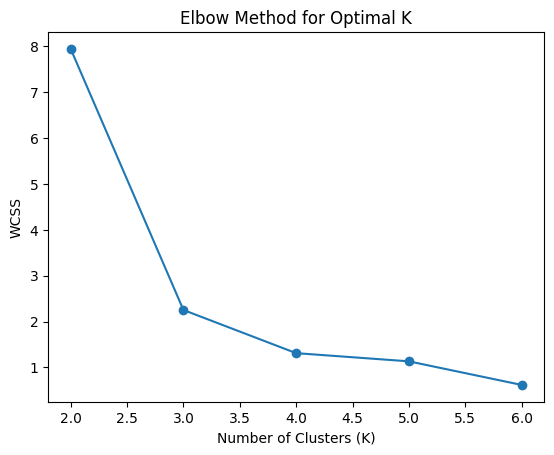


Final Student Clusters:
   student_id  GPA  study_hours  attendance_rate  Cluster
0         101  3.8           25               95        2
1         102  2.5           10               60        0
2         103  3.2           18               80        1
3         104  1.9            5               50        0
4         105  3.5           22               90        2
5         106  2.0            6               55        0
6         107  3.9           28               98        2
7         108  2.8           15               70        1
8         109  3.0           17               75        1
9         110  2.2            8               65        0


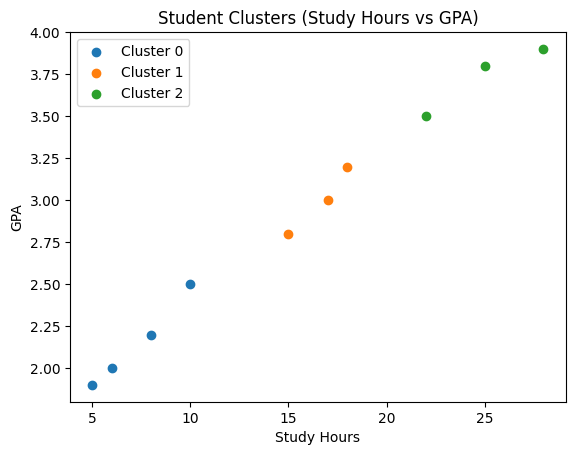

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    "student_id": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "GPA": [3.8, 2.5, 3.2, 1.9, 3.5, 2.0, 3.9, 2.8, 3.0, 2.2],
    "study_hours": [25, 10, 18, 5, 22, 6, 28, 15, 17, 8],
    "attendance_rate": [95, 60, 80, 50, 90, 55, 98, 70, 75, 65]
}

df = pd.DataFrame(data)

features = df[["GPA", "study_hours", "attendance_rate"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

wcss = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 7), wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)
print("\nFinal Student Clusters:")
print(df)

plt.figure()

for cluster in range(k_optimal):
    plt.scatter(
        df[df["Cluster"] == cluster]["study_hours"],
        df[df["Cluster"] == cluster]["GPA"],
        label=f"Cluster {cluster}"
    )

plt.title("Student Clusters (Study Hours vs GPA)")
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.legend()
plt.show()